# Custom TorchVision Transforms

* Module Name: workbench-transforms.ipynb
* Description: Visualise custom TorchVision transforms

Copyright (C) 2025 J.Cincotta

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program. If not, see <https://www.gnu.org/licenses/>.


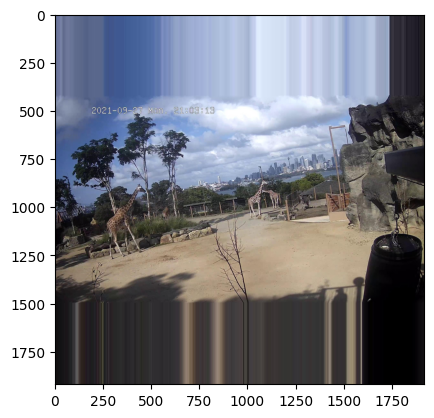

In [9]:
import torchvision
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from welfareobs.utils.padded_square_transform import PaddedSquareTransform


def dump_image(image):    # Convert ImageList to a batch of tensors
    img = (image.cpu().permute(1, 2, 0).numpy())[ :, :, [0, 1, 2]]
    img = np.interp(img, (img.min(), img.max()), (0, 255)).astype(np.uint8)
    plt.imshow(img)
    plt.show()


size = 1920
image = Image.open("/project/data/wod_reid/images/c1-savannah-2024_03_26__23_03_54.jpg")
transform = torchvision.transforms.Compose([
    PaddedSquareTransform(fill=0, padding_mode="edge"),
    torchvision.transforms.PILToTensor(), # Convert a PIL Image or ndarray to tensor and scale the values 0->255 to 0.0->1.0
    torchvision.transforms.Resize(
        size=(size,size),
        interpolation=torchvision.transforms.InterpolationMode.BILINEAR,
        max_size=None,
        antialias=True
    ),
])
image = transform(image)
dump_image(image)
